In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:


import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\thung\Downloads\extended_fmcg_demand_forecasting.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Rename Sales_Volume to Sales
df.rename(columns={"Sales_Volume": "Sales"}, inplace=True)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Dataset loaded successfully!
Shape: (1000, 10)
Columns: ['Date', 'Product_Category', 'Sales', 'Price', 'Promotion', 'Store_Location', 'Weekday', 'Supplier_Cost', 'Replenishment_Lead_Time', 'Stock_Level']


,Date,Product_Category,Sales,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [11]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nFirst 10 Rows:")
display(df.head(10))

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (1000, 10)

Column Names:
['Date', 'Product_Category', 'Sales', 'Price', 'Promotion', 'Store_Location', 'Weekday', 'Supplier_Cost', 'Replenishment_Lead_Time', 'Stock_Level']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     1000 non-null   datetime64[us]
 1   Product_Category         1000 non-null   str           
 2   Sales                    1000 non-null   int64         
 3   Price                    1000 non-null   float64       
 4   Promotion                1000 non-null   int64         
 5   Store_Location           1000 non-null   str           
 6   Weekday                  1000 non-null   int64         
 7   Supplier_Cost            1000 non-null   float64       
 8   Replenishment_Lead_Time  1000 non-null   int64         
 9   Stock_Level       

,Date,Product_Category,Sales,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334
5,2022-01-06,Snacks,1256,19.254830,1,Urban,3,13.013454,1,245
6,2022-01-07,Dairy,987,8.902240,0,Suburban,4,13.348355,7,356
7,2022-01-08,Dairy,1928,17.078661,0,Rural,5,3.351477,4,201
8,2022-01-09,Dairy,1963,12.946532,1,Rural,6,11.192678,5,63
9,2022-01-10,Personal Care,226,14.971656,1,Urban,0,4.654533,6,374



Statistical Summary:


,Date,Sales,Price,Promotion,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2023-05-15 12:00:00,1048.781000,10.362358,0.491000,2.999000,7.552047,4.970000,266.494000
min,2022-01-01 00:00:00,101.000000,1.003580,0.000000,0.000000,0.500445,1.000000,50.000000
25%,2022-09-07 18:00:00,591.750000,5.541108,0.000000,1.000000,3.887763,3.000000,152.000000
50%,2023-05-15 12:00:00,1064.500000,10.404366,0.000000,3.000000,7.422058,5.000000,260.000000
75%,2024-01-20 06:00:00,1489.000000,15.054035,1.000000,5.000000,11.099853,7.000000,376.000000
max,2024-09-26 00:00:00,1997.000000,19.944485,1.000000,6.000000,14.993587,9.000000,499.000000
std,NaN,539.688298,5.420627,0.500169,2.001751,4.163729,2.589944,130.560078


In [12]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date                       0
Product_Category           0
Sales                      0
Price                      0
Promotion                  0
Store_Location             0
Weekday                    0
Supplier_Cost              0
Replenishment_Lead_Time    0
Stock_Level                0
dtype: int64


In [13]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(df.dtypes)

Date                       datetime64[us]
Product_Category                      str
Sales                               int64
Price                             float64
Promotion                           int64
Store_Location                        str
Weekday                             int64
Supplier_Cost                     float64
Replenishment_Lead_Time             int64
Stock_Level                         int64
dtype: object


In [15]:
print("Negative sales:", (df["Sales"] < 0).sum())
print("Zero sales:", (df["Sales"] == 0).sum())

# Replace invalid values if any
df["Sales"] = df["Sales"].clip(lower=0)

print("Data cleaning completed.")

Negative sales: 0
Zero sales: 0
Data cleaning completed.


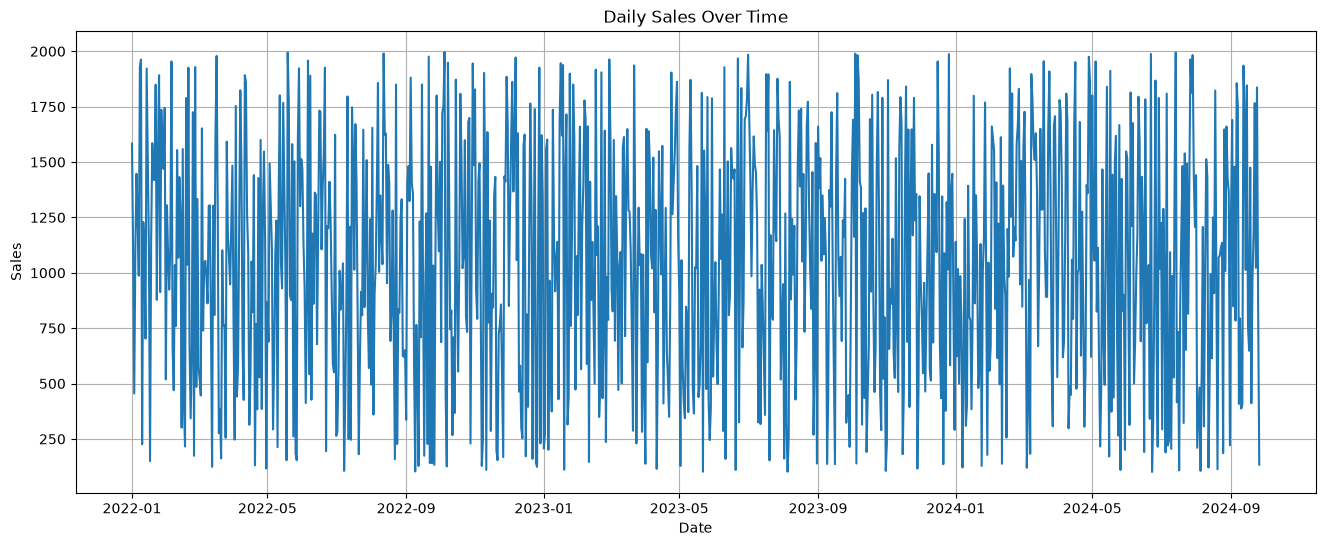

In [16]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["Date"],
    df["Sales"]
)

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

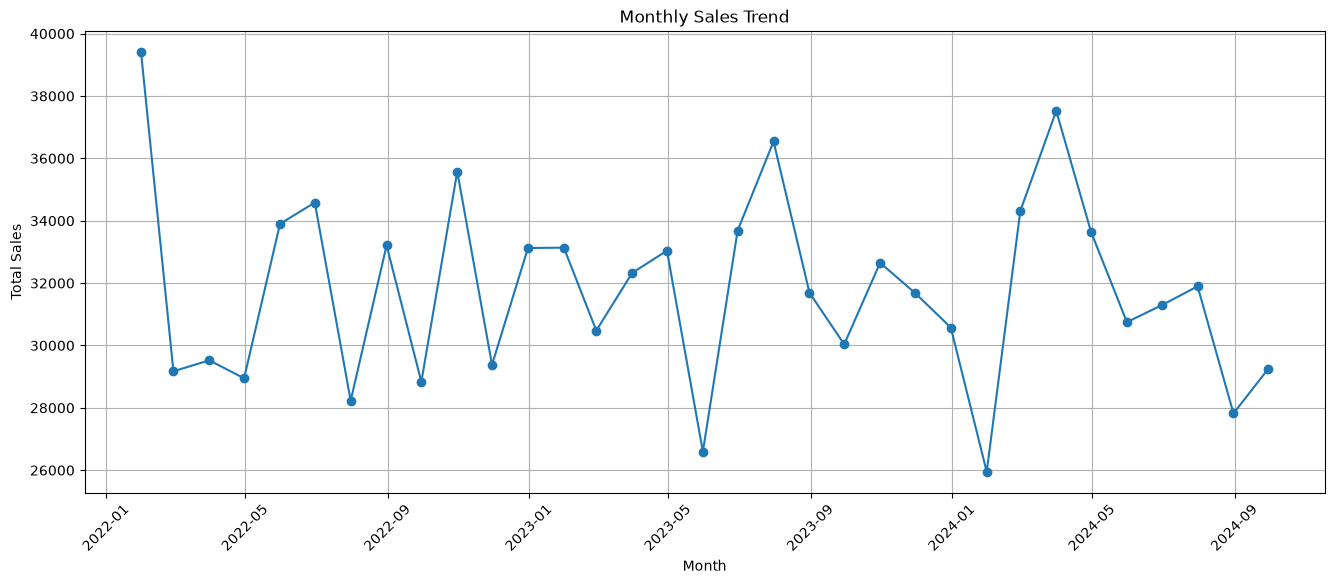

In [17]:
monthly_sales = (
    df.set_index("Date")["Sales"]
    .resample("ME")
    .sum()
)

plt.figure(figsize=(16, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

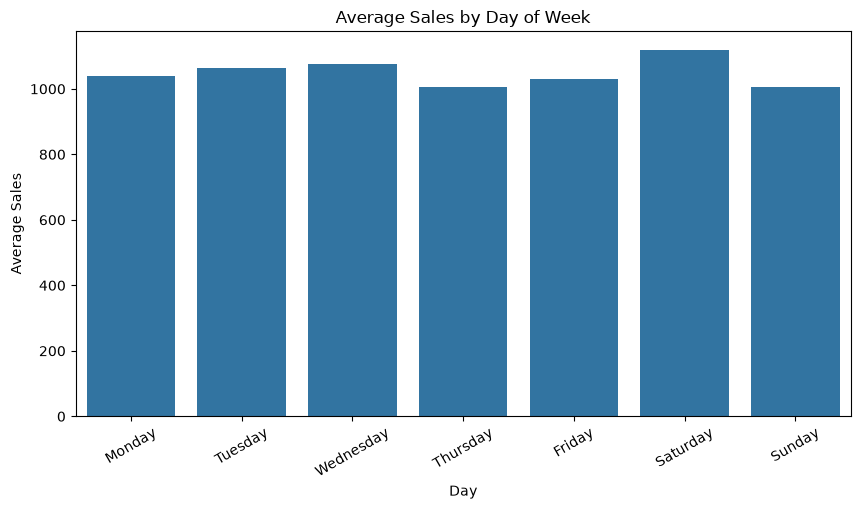

In [20]:


day_sales = df.groupby("Weekday")["Sales"].mean()

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_names,
    y=day_sales.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.xticks(rotation=30)

plt.show()

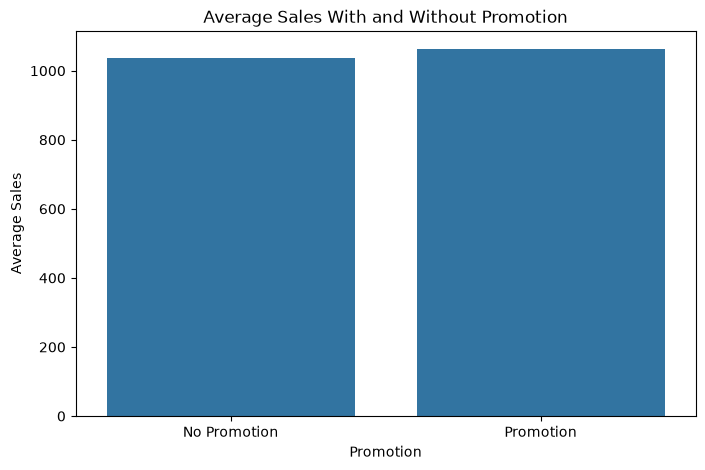

In [21]:
promotion_sales = df.groupby("Promotion")["Sales"].mean()

promotion_sales.index = [
    "No Promotion",
    "Promotion"
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=promotion_sales.index,
    y=promotion_sales.values
)

plt.title("Average Sales With and Without Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.show()

In [22]:
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

print(df.head())

        Date Product_Category  Sales      Price  Promotion Store_Location  \
0 2022-01-01        Household   1583   5.190661          0          Urban   
1 2022-01-02    Personal Care   1103   8.949596          0          Urban   
2 2022-01-03            Dairy    455   4.867987          0          Rural   
3 2022-01-04    Personal Care   1107  16.968596          1          Urban   
4 2022-01-05    Personal Care   1447   4.309673          1          Rural   

   Weekday  Supplier_Cost  Replenishment_Lead_Time  Stock_Level  Day  Month  \
0        5       9.299281                        9          207    1      1   
1        6      13.274109                        5          253    2      1   
2        0      13.302265                        9          245    3      1   
3        1      10.056158                        5          265    4      1   
4        2       3.562862                        8          334    5      1   

   Quarter  WeekOfYear  DayOfWeek  IsWeekend  
0        1     

In [23]:
# Lag features
df["Lag_1"] = df["Sales"].shift(1)
df["Lag_7"] = df["Sales"].shift(7)
df["Lag_14"] = df["Sales"].shift(14)
df["Lag_28"] = df["Sales"].shift(28)

# Rolling averages
df["RollingMean_7"] = (
    df["Sales"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

df["RollingMean_14"] = (
    df["Sales"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

df["RollingMean_28"] = (
    df["Sales"]
    .shift(1)
    .rolling(window=28)
    .mean()
)

# Rolling standard deviation
df["RollingStd_7"] = (
    df["Sales"]
    .shift(1)
    .rolling(window=7)
    .std()
)

# Remove rows created by lag features
df = df.dropna().reset_index(drop=True)

display(df.head())

,Date,Product_Category,Sales,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level,...,DayOfWeek,IsWeekend,Lag_1,Lag_7,Lag_14,Lag_28,RollingMean_7,RollingMean_14,RollingMean_28,RollingStd_7
0,2022-01-29,Household,1469,15.744004,0,Suburban,5,3.556500,8,320,...,5,1,1528.0,1849.0,1501.0,1583.0,1475.142857,1333.285714,1274.392857,420.311959
1,2022-01-30,Household,1745,8.700893,0,Rural,6,3.825804,3,461,...,6,1,1469.0,878.0,1113.0,1103.0,1420.857143,1331.000000,1270.321429,387.215026
2,2022-01-31,Dairy,519,12.435252,0,Rural,0,7.302055,2,457,...,0,0,1745.0,1530.0,150.0,455.0,1544.714286,1376.142857,1293.250000,316.913087
3,2022-02-01,Household,1305,13.018270,1,Urban,1,4.394151,1,237,...,1,0,519.0,1892.0,1152.0,1107.0,1400.285714,1402.500000,1295.535714,501.407923
4,2022-02-02,Household,1082,8.084124,0,Urban,2,1.964183,4,468,...,2,0,1305.0,913.0,1585.0,1447.0,1316.428571,1413.428571,1302.607143,452.130459


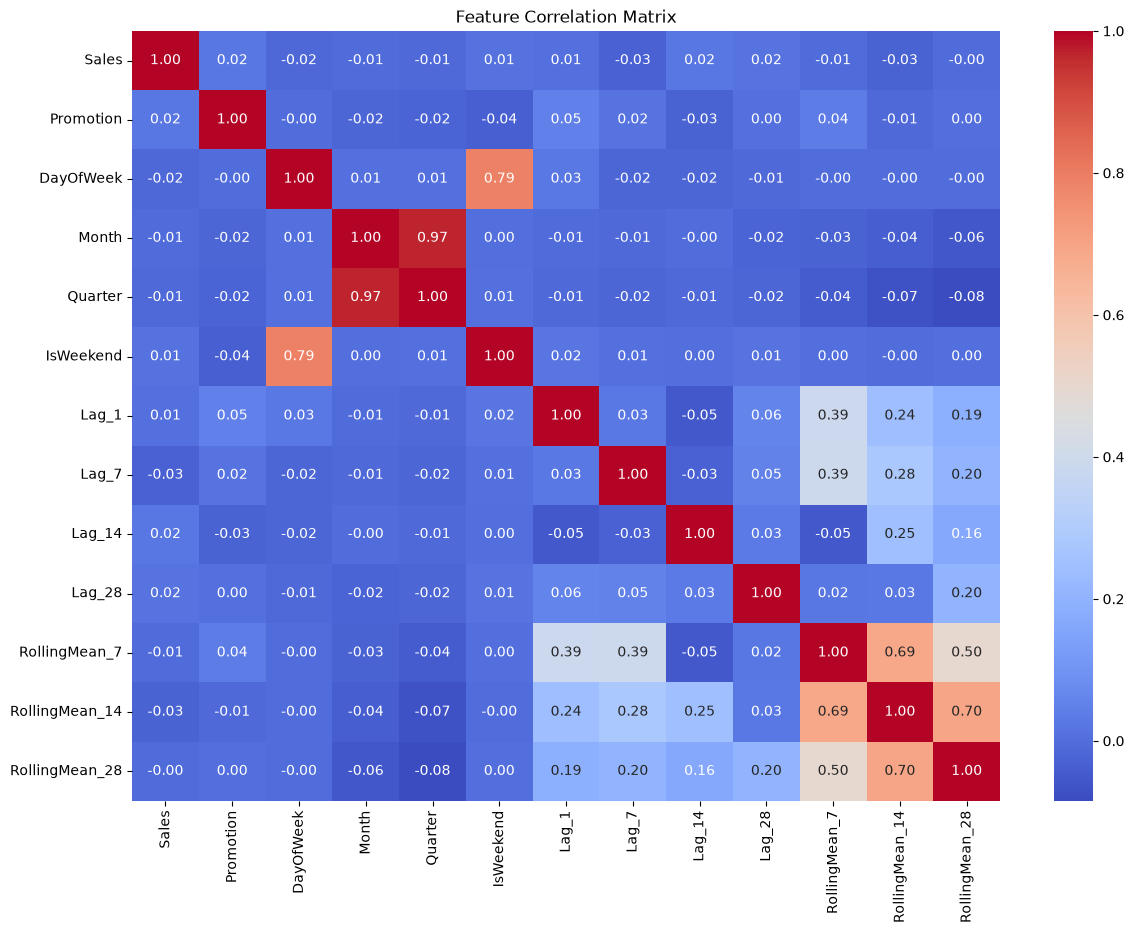

In [24]:
correlation_columns = [
    "Sales",
    "Promotion",
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "RollingMean_7",
    "RollingMean_14",
    "RollingMean_28"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [25]:
features = [
    "Day",
    "Month",
    "Quarter",
    "WeekOfYear",
    "DayOfWeek",
    "IsWeekend",
    "Promotion",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "RollingMean_7",
    "RollingMean_14",
    "RollingMean_28",
    "RollingStd_7"
]

target = "Sales"

X = df[features]
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (972, 15)
Target shape: (972,)


In [26]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df["Date"].iloc[:split_index].min())
print(df["Date"].iloc[:split_index].max())

print("\nTesting period:")
print(df["Date"].iloc[split_index:].min())
print(df["Date"].iloc[split_index:].max())

Training samples: 777
Testing samples: 195

Training period:
2022-01-29 00:00:00
2024-03-15 00:00:00

Testing period:
2024-03-16 00:00:00
2024-09-26 00:00:00


In [27]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Model training completed!


In [28]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Date": df.iloc[split_index:]["Date"].values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

prediction_df.head(10)

,Date,Actual_Sales,Predicted_Sales
0,2024-03-16,1650,1082.123092
1,2024-03-17,1285,1254.794685
2,2024-03-18,1286,990.214374
3,2024-03-19,1955,1166.476466
4,2024-03-20,1108,1074.128690
5,2024-03-21,892,997.230494
6,2024-03-22,891,1030.743842
7,2024-03-23,1647,1057.766687
8,2024-03-24,1909,1109.581876
9,2024-03-25,1394,1083.533657


In [29]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

mape = np.mean(
    np.abs(
        (y_test - y_pred) / y_test
    )
) * 100

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

MODEL EVALUATION
MAE  : 472.04
RMSE : 553.60
R²   : 0.0151
MAPE : 101.32%


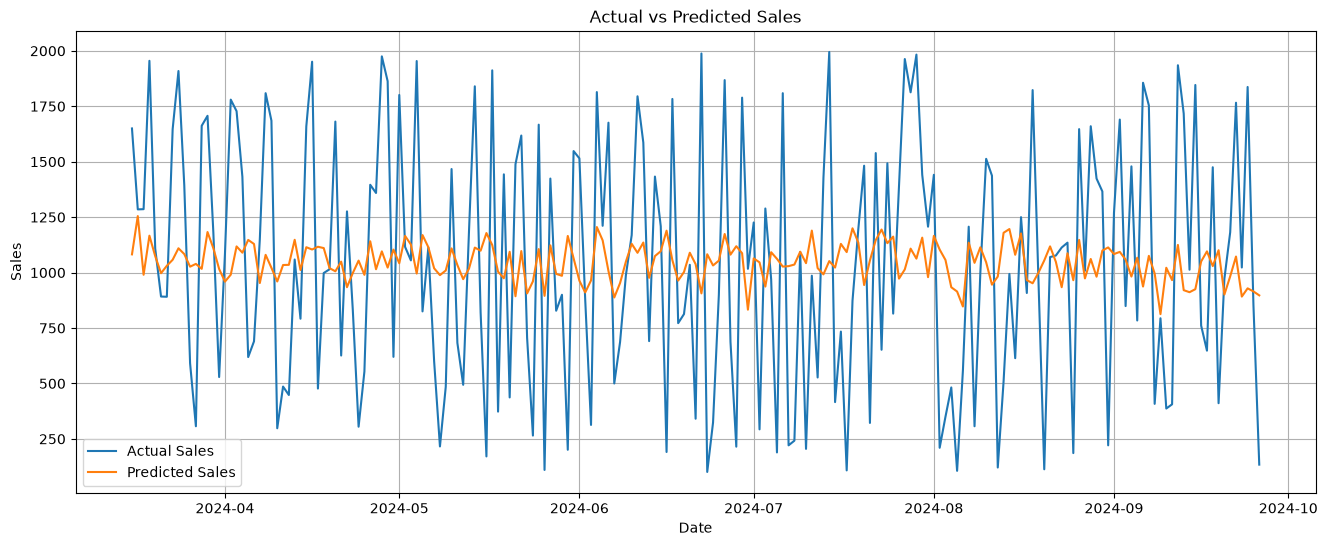

In [30]:
plt.figure(figsize=(16, 6))

plt.plot(
    prediction_df["Date"],
    prediction_df["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    prediction_df["Date"],
    prediction_df["Predicted_Sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [31]:
prediction_df["Error"] = (
    prediction_df["Actual_Sales"]
    - prediction_df["Predicted_Sales"]
)

prediction_df["Absolute_Error"] = (
    prediction_df["Error"].abs()
)

prediction_df["Percentage_Error"] = (
    prediction_df["Absolute_Error"]
    / prediction_df["Actual_Sales"]
) * 100

display(
    prediction_df.head(10)
)

,Date,Actual_Sales,Predicted_Sales,Error,Absolute_Error,Percentage_Error
0,2024-03-16,1650,1082.123092,567.876908,567.876908,34.416782
1,2024-03-17,1285,1254.794685,30.205315,30.205315,2.350608
2,2024-03-18,1286,990.214374,295.785626,295.785626,23.000437
3,2024-03-19,1955,1166.476466,788.523534,788.523534,40.333685
4,2024-03-20,1108,1074.128690,33.871310,33.871310,3.056977
5,2024-03-21,892,997.230494,-105.230494,105.230494,11.797141
6,2024-03-22,891,1030.743842,-139.743842,139.743842,15.683933
7,2024-03-23,1647,1057.766687,589.233313,589.233313,35.776157
8,2024-03-24,1909,1109.581876,799.418124,799.418124,41.876277
9,2024-03-25,1394,1083.533657,310.466343,310.466343,22.271617


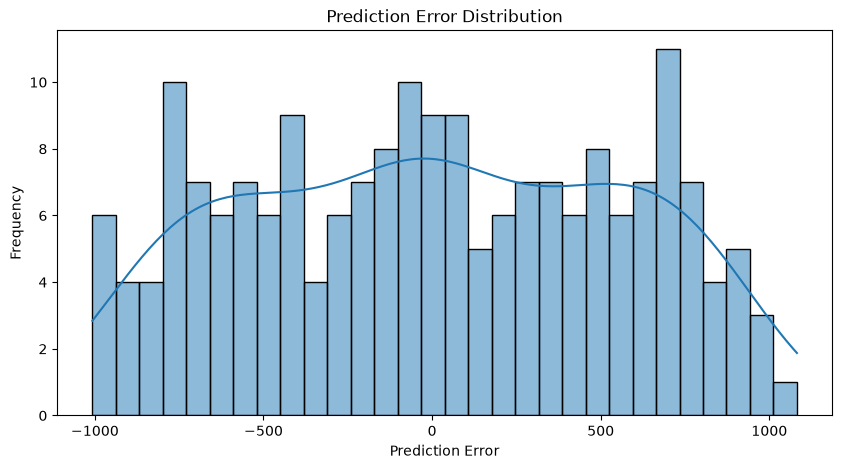

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    prediction_df["Error"],
    bins=30,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(feature_importance)

,Feature,Importance
14,RollingStd_7,0.108230
10,Lag_28,0.103614
8,Lag_7,0.102887
11,RollingMean_7,0.100888
7,Lag_1,0.100715
9,Lag_14,0.095748
13,RollingMean_28,0.092037
12,RollingMean_14,0.089275
0,Day,0.070702
3,WeekOfYear,0.059731


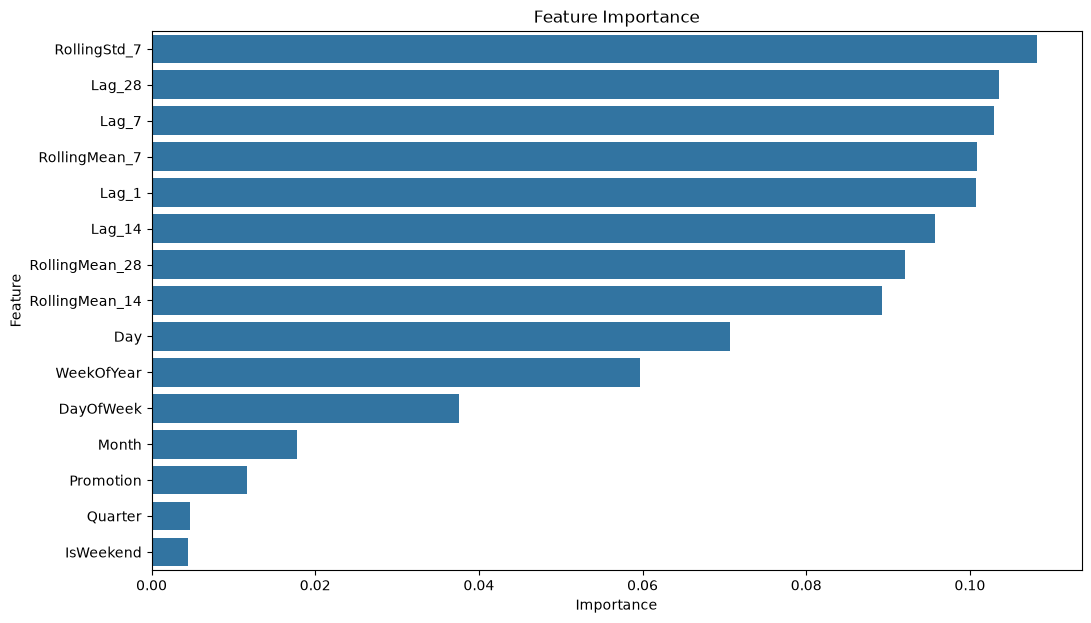

In [34]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [35]:
# Number of future days
forecast_days = 30

# Work on a copy
history = df.copy()

future_predictions = []

last_date = history["Date"].max()

for i in range(1, forecast_days + 1):

    future_date = last_date + pd.Timedelta(days=i)

    # Calendar features
    day = future_date.day
    month = future_date.month
    quarter = future_date.quarter
    week_of_year = future_date.isocalendar().week
    day_of_week = future_date.dayofweek

    is_weekend = int(day_of_week >= 5)

    # For future promotion:
    # assume no promotion unless known
    promotion = 0

    # Recent sales
    sales_values = history["Sales"].values

    lag_1 = sales_values[-1]
    lag_7 = sales_values[-7]
    lag_14 = sales_values[-14]
    lag_28 = sales_values[-28:]

    rolling_mean_7 = np.mean(
        sales_values[-7:]
    )

    rolling_mean_14 = np.mean(
        sales_values[-14:]
    )

    rolling_mean_28 = np.mean(
        sales_values[-28:]
    )

    rolling_std_7 = np.std(
        sales_values[-7:]
    )

    # Create feature row
    future_features = pd.DataFrame([{
        "Day": day,
        "Month": month,
        "Quarter": quarter,
        "WeekOfYear": int(week_of_year),
        "DayOfWeek": day_of_week,
        "IsWeekend": is_weekend,
        "Promotion": promotion,
        "Lag_1": lag_1,
        "Lag_7": lag_7,
        "Lag_14": lag_14,
        "Lag_28": lag_28[-1],
        "RollingMean_7": rolling_mean_7,
        "RollingMean_14": rolling_mean_14,
        "RollingMean_28": rolling_mean_28,
        "RollingStd_7": rolling_std_7
    }])

    # Predict
    predicted_sales = model.predict(
        future_features[features]
    )[0]

    predicted_sales = max(
        0,
        predicted_sales
    )

    # Save prediction
    future_predictions.append({
        "Date": future_date,
        "Forecasted_Sales": predicted_sales
    })

    # Add prediction to history
    new_row = pd.DataFrame([{
        "Date": future_date,
        "Sales": predicted_sales
    }])

    history = pd.concat(
        [history[["Date", "Sales"]], new_row],
        ignore_index=True
    )


future_forecast = pd.DataFrame(
    future_predictions
)

display(future_forecast)

,Date,Forecasted_Sales
0,2024-09-27,1078.417949
1,2024-09-28,1176.125298
2,2024-09-29,967.690178
3,2024-09-30,958.175196
4,2024-10-01,929.291004
5,2024-10-02,910.682615
6,2024-10-03,826.476682
7,2024-10-04,657.749244
8,2024-10-05,653.760740
9,2024-10-06,783.799961


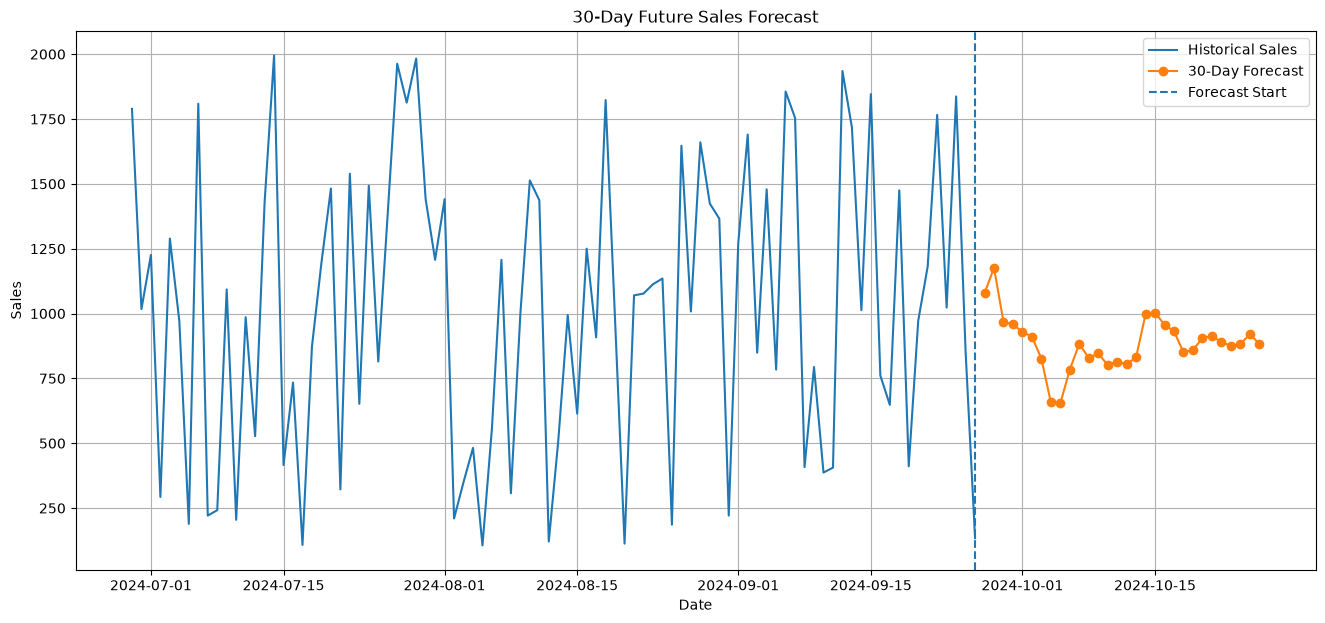

In [36]:
plt.figure(figsize=(16, 7))

# Historical sales
plt.plot(
    df["Date"].tail(90),
    df["Sales"].tail(90),
    label="Historical Sales"
)

# Future forecast
plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted_Sales"],
    marker="o",
    label="30-Day Forecast"
)

plt.axvline(
    x=df["Date"].max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title("30-Day Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [37]:
business_forecast = future_forecast.copy()

business_forecast["Forecasted_Sales"] = (
    business_forecast["Forecasted_Sales"]
    .round(0)
    .astype(int)
)

display(business_forecast)

,Date,Forecasted_Sales
0,2024-09-27,1078
1,2024-09-28,1176
2,2024-09-29,968
3,2024-09-30,958
4,2024-10-01,929
5,2024-10-02,911
6,2024-10-03,826
7,2024-10-04,658
8,2024-10-05,654
9,2024-10-06,784


In [38]:
total_forecast = (
    future_forecast["Forecasted_Sales"]
    .sum()
)

average_forecast = (
    future_forecast["Forecasted_Sales"]
    .mean()
)

maximum_forecast = (
    future_forecast["Forecasted_Sales"]
    .max()
)

minimum_forecast = (
    future_forecast["Forecasted_Sales"]
    .min()
)

max_date = future_forecast.loc[
    future_forecast["Forecasted_Sales"].idxmax(),
    "Date"
]

min_date = future_forecast.loc[
    future_forecast["Forecasted_Sales"].idxmin(),
    "Date"
]

print("=" * 55)
print("30-DAY BUSINESS FORECAST SUMMARY")
print("=" * 55)

print(f"Total expected sales : {total_forecast:,.0f}")
print(f"Average daily sales  : {average_forecast:,.2f}")
print(f"Maximum forecast     : {maximum_forecast:,.2f}")
print(f"Minimum forecast     : {minimum_forecast:,.2f}")

print(f"\nHighest sales expected on: {max_date.date()}")
print(f"Lowest sales expected on : {min_date.date()}")

30-DAY BUSINESS FORECAST SUMMARY
Total expected sales : 26,623
Average daily sales  : 887.43
Maximum forecast     : 1,176.13
Minimum forecast     : 653.76

Highest sales expected on: 2024-09-28
Lowest sales expected on : 2024-10-05


In [39]:
future_forecast["Week"] = (
    future_forecast["Date"]
    .dt.isocalendar()
    .week
)

weekly_forecast = (
    future_forecast
    .groupby("Week")["Forecasted_Sales"]
    .sum()
    .reset_index()
)

display(weekly_forecast)

,Week,Forecasted_Sales
0,39,3222.233425
1,40,5719.935443
2,41,5810.126767
3,42,6505.264614
4,43,5365.272575


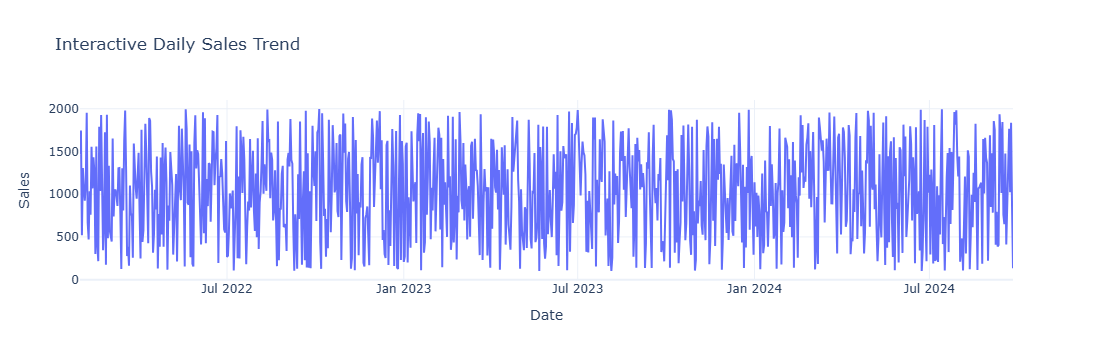

In [40]:
fig = px.line(
    df,
    x="Date",
    y="Sales",
    title="Interactive Daily Sales Trend",
    labels={
        "Sales": "Sales",
        "Date": "Date"
    }
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

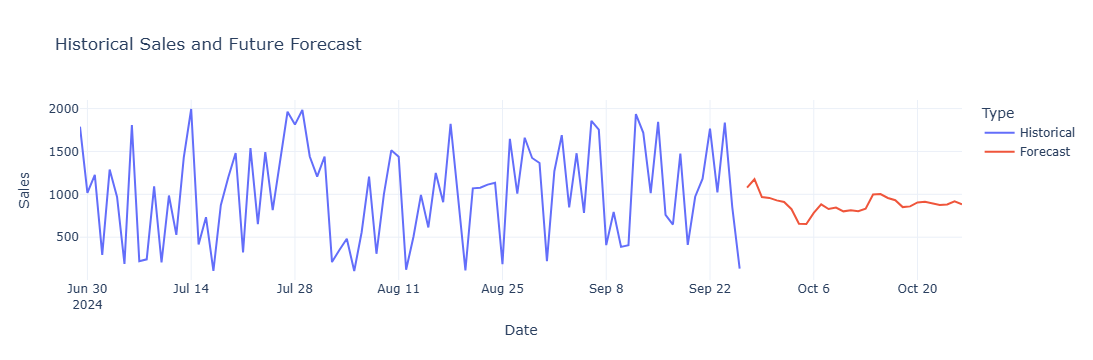

In [41]:
historical_plot = df[
    ["Date", "Sales"]
].tail(90).copy()

historical_plot["Type"] = "Historical"

forecast_plot = future_forecast[
    ["Date", "Forecasted_Sales"]
].copy()

forecast_plot = forecast_plot.rename(
    columns={
        "Forecasted_Sales": "Sales"
    }
)

forecast_plot["Type"] = "Forecast"

combined_plot = pd.concat(
    [
        historical_plot,
        forecast_plot
    ],
    ignore_index=True
)

fig = px.line(
    combined_plot,
    x="Date",
    y="Sales",
    color="Type",
    title="Historical Sales and Future Forecast",
    labels={
        "Sales": "Sales",
        "Date": "Date"
    }
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

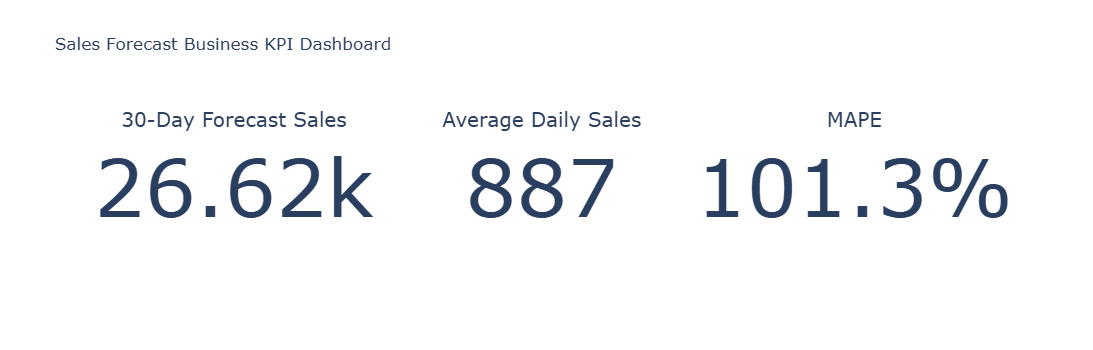

In [42]:
fig = go.Figure()

# KPI 1
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_forecast,
        title={
            "text": "30-Day Forecast Sales"
        },
        domain={
            "x": [0, 0.33],
            "y": [0, 1]
        }
    )
)

# KPI 2
fig.add_trace(
    go.Indicator(
        mode="number",
        value=average_forecast,
        title={
            "text": "Average Daily Sales"
        },
        domain={
            "x": [0.33, 0.66],
            "y": [0, 1]
        }
    )
)

# KPI 3
fig.add_trace(
    go.Indicator(
        mode="number",
        value=mape,
        number={
            "suffix": "%"
        },
        title={
            "text": "MAPE"
        },
        domain={
            "x": [0.66, 1],
            "y": [0, 1]
        }
    )
)

fig.update_layout(
    title="Sales Forecast Business KPI Dashboard",
    height=350
)

fig.show()

In [43]:
future_forecast.to_csv(
    "sales_forecast_30_days.csv",
    index=False
)

prediction_df.to_csv(
    "model_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [44]:
print("\n")
print("=" * 70)
print("SALES & DEMAND FORECASTING - FINAL PROJECT REPORT")
print("=" * 70)

print("\n1. DATASET")
print(f"Total historical records: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

print("\n2. MODEL")
print("Algorithm: Random Forest Regression")
print("Forecasting approach: Time-based lag and rolling features")

print("\n3. MODEL PERFORMANCE")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

print("\n4. FUTURE FORECAST")
print(f"Forecast horizon: {forecast_days} days")
print(f"Expected total sales: {total_forecast:,.0f}")
print(f"Expected average daily sales: {average_forecast:,.2f}")

print("\n5. BUSINESS INSIGHTS")
print(f"Highest expected sales date: {max_date.date()}")
print(f"Lowest expected sales date: {min_date.date()}")

print("\n6. TOP IMPORTANT FEATURES")

for i, row in feature_importance.head(5).iterrows():
    print(
        f"- {row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

print("\n7. RECOMMENDATIONS")
print("- Use the forecast to plan inventory.")
print("- Increase staffing during high-demand periods.")
print("- Plan promotions around low-demand periods.")
print("- Monitor forecast errors regularly.")
print("- Retrain the model when new sales data becomes available.")

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)



SALES & DEMAND FORECASTING - FINAL PROJECT REPORT

1. DATASET
Total historical records: 972
Date range: 2022-01-29 to 2024-09-26

2. MODEL
Algorithm: Random Forest Regression
Forecasting approach: Time-based lag and rolling features

3. MODEL PERFORMANCE
MAE  : 472.04
RMSE : 553.60
R²   : 0.0151
MAPE : 101.32%

4. FUTURE FORECAST
Forecast horizon: 30 days
Expected total sales: 26,623
Expected average daily sales: 887.43

5. BUSINESS INSIGHTS
Highest expected sales date: 2024-09-28
Lowest expected sales date: 2024-10-05

6. TOP IMPORTANT FEATURES
- RollingStd_7: 0.1082
- Lag_28: 0.1036
- Lag_7: 0.1029
- RollingMean_7: 0.1009
- Lag_1: 0.1007

7. RECOMMENDATIONS
- Use the forecast to plan inventory.
- Increase staffing during high-demand periods.
- Plan promotions around low-demand periods.
- Monitor forecast errors regularly.
- Retrain the model when new sales data becomes available.

PROJECT COMPLETED SUCCESSFULLY
